In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

In [62]:
data = pd.read_csv("BellPoints.csv")
data

,OID_,Waypoint,Name,WaterElevation,GainingLosing,WaterElevationFT,x,y
0,2,NaN,P1,272.890015,NaN,895.320007,-93.148845,44.461057
1,3,NaN,P2,272.820007,NaN,895.090027,-93.147879,44.460921
2,5,NaN,P3,272.989990,NaN,895.630005,-93.147206,44.460888
3,6,NaN,P4,274.089996,NaN,899.260010,-93.146881,44.459973
4,7,NaN,P5,273.880005,NaN,898.559998,-93.146947,44.458780
5,8,NaN,C1,272.579987,NaN,894.289978,-93.148845,44.461072
6,9,NaN,C2 upstream,272.929993,NaN,895.440002,-93.147859,44.460939
7,10,NaN,C2 downstream,272.250000,NaN,893.210022,-93.147874,44.460946
8,11,NaN,C3,272.970001,NaN,895.570007,-93.147211,44.460958
9,12,NaN,C4,272.880005,NaN,895.291016,-93.146813,44.459976


In [63]:
data2 = pd.read_csv("BellPointsDiffPos.csv")
data2

,OID_,Waypoint,Name,WaterElevation,GainingLosing,WaterElevationFT,x,y
0,2,NaN,P1,272.890015,NaN,895.320007,488159.310482,4.923094e+06
1,3,NaN,P2,272.820007,NaN,895.090027,488236.136582,4.923079e+06
2,5,NaN,P3,272.989990,NaN,895.630005,488289.640482,4.923075e+06
3,6,NaN,P4,274.089996,NaN,899.260010,488315.287282,4.922974e+06
4,7,NaN,P5,273.880005,NaN,898.559998,488309.809182,4.922841e+06
5,8,NaN,C1,272.579987,NaN,894.289978,488159.321982,4.923096e+06
6,9,NaN,C2 upstream,272.929993,NaN,895.440002,488237.688782,4.923081e+06
7,10,NaN,C2 downstream,272.250000,NaN,893.210022,488236.543082,4.923082e+06
8,11,NaN,C3,272.970001,NaN,895.570007,488289.242182,4.923083e+06
9,12,NaN,C4,272.880005,NaN,895.291016,488320.678382,4.922974e+06


In [64]:
#pip install geopandas

In [65]:
#pip install contextily

In [66]:
#pip install folium

In [67]:
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
import rasterio.plot
import contextily as cx
import folium

In [68]:
bell = gpd.read_file('Bell2026Shape.gpkg')
# nz_height = gpd.read_file('data/nz_height.gpkg')
# nz_elev = rasterio.open('data/nz_elev.tif')

In [69]:
bell

,AreaFT,geometry
0,530754.876708,"MULTIPOLYGON Z (((488098.348 4923122.167 0, 48..."


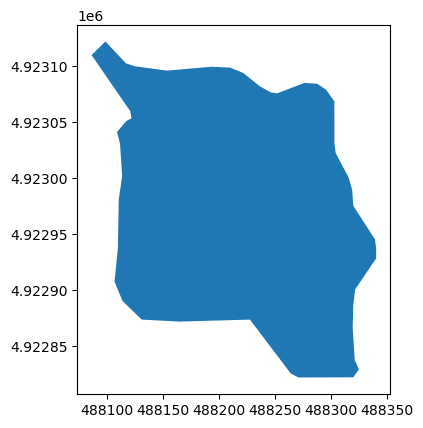

In [70]:
bell.plot();

In [71]:
data2 = gpd.GeoDataFrame(data2)
data2

,OID_,Waypoint,Name,WaterElevation,GainingLosing,WaterElevationFT,x,y
0,2,NaN,P1,272.890015,NaN,895.320007,488159.310482,4.923094e+06
1,3,NaN,P2,272.820007,NaN,895.090027,488236.136582,4.923079e+06
2,5,NaN,P3,272.989990,NaN,895.630005,488289.640482,4.923075e+06
3,6,NaN,P4,274.089996,NaN,899.260010,488315.287282,4.922974e+06
4,7,NaN,P5,273.880005,NaN,898.559998,488309.809182,4.922841e+06
5,8,NaN,C1,272.579987,NaN,894.289978,488159.321982,4.923096e+06
6,9,NaN,C2 upstream,272.929993,NaN,895.440002,488237.688782,4.923081e+06
7,10,NaN,C2 downstream,272.250000,NaN,893.210022,488236.543082,4.923082e+06
8,11,NaN,C3,272.970001,NaN,895.570007,488289.242182,4.923083e+06
9,12,NaN,C4,272.880005,NaN,895.291016,488320.678382,4.922974e+06


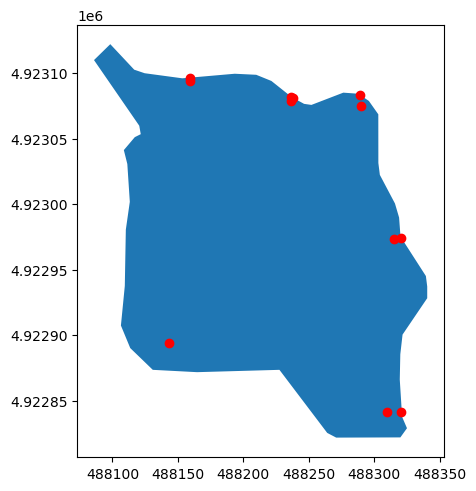

In [72]:
fig, ax = plt.subplots(layout='constrained')

bell.plot(ax=ax)
ax.scatter(data2.x, data2.y, color = "r")

plt.show();

In [73]:
from shapely import Point

In [74]:
from shapely.geometry import LineString

In [75]:
from scipy.interpolate import griddata

In [76]:
data2 = gpd.GeoDataFrame(
    data2,
    geometry=gpd.points_from_xy(data2['x'], data2['y']))

In [77]:
data2

,OID_,Waypoint,Name,WaterElevation,GainingLosing,WaterElevationFT,x,y,geometry
0,2,NaN,P1,272.890015,NaN,895.320007,488159.310482,4.923094e+06,POINT (488159.31 4923094.279)
1,3,NaN,P2,272.820007,NaN,895.090027,488236.136582,4.923079e+06,POINT (488236.137 4923079.035)
2,5,NaN,P3,272.989990,NaN,895.630005,488289.640482,4.923075e+06,POINT (488289.64 4923075.225)
3,6,NaN,P4,274.089996,NaN,899.260010,488315.287282,4.922974e+06,POINT (488315.287 4922973.533)
4,7,NaN,P5,273.880005,NaN,898.559998,488309.809182,4.922841e+06,POINT (488309.809 4922841.107)
5,8,NaN,C1,272.579987,NaN,894.289978,488159.321982,4.923096e+06,POINT (488159.322 4923095.989)
6,9,NaN,C2 upstream,272.929993,NaN,895.440002,488237.688782,4.923081e+06,POINT (488237.689 4923081.029)
7,10,NaN,C2 downstream,272.250000,NaN,893.210022,488236.543082,4.923082e+06,POINT (488236.543 4923081.75)
8,11,NaN,C3,272.970001,NaN,895.570007,488289.242182,4.923083e+06,POINT (488289.242 4923083.066)
9,12,NaN,C4,272.880005,NaN,895.291016,488320.678382,4.922974e+06,POINT (488320.678 4922973.887)


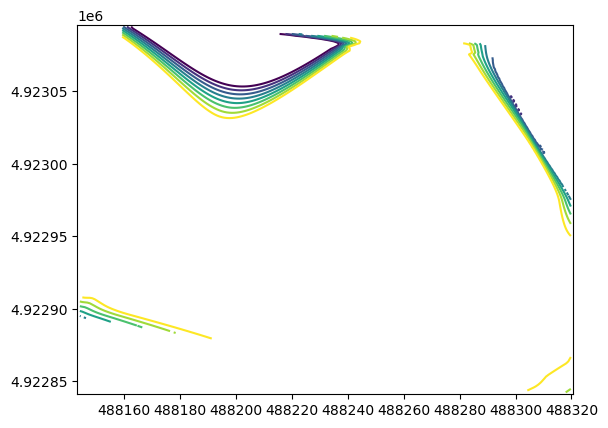

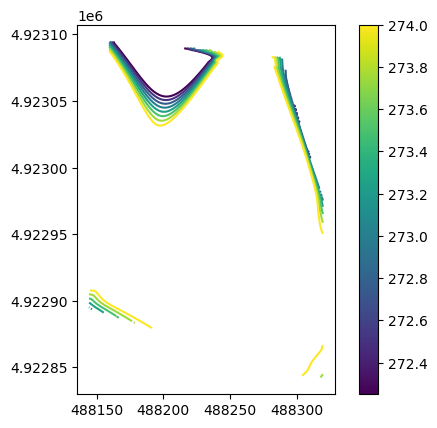

In [78]:
# from google gemnini and I don't fully understand
x = data2.x
y = data2.y
z = data2["WaterElevation"]

# I think this is interpolating the data in data2 onto a grid because it's essentially random points scattered around random space as is
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 200), 
    np.linspace(y.min(), y.max(), 200)
)
grid_z = griddata((x, y), z , (grid_x, grid_y), method = 'cubic')

levels = np.arange(z.min(), z.max(), 0.25) #0.25 is the contour interval
cs = plt.contour(grid_x, grid_y, grid_z, levels=levels)

lines = []
for level, segments in zip(cs.levels, cs.allsegs):
    for line in segments:
        if len(line) >= 2:
            lines.append({'head': level, 'geometry': LineString(line)})

contour_data2 = gpd.GeoDataFrame(lines, crs = data2.crs)

contour_data2.plot(column='head', cmap='viridis', legend=True)
plt.show()

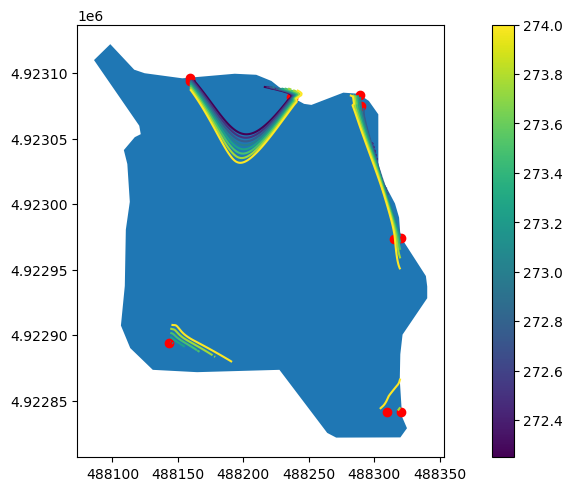

In [79]:
fig, ax = plt.subplots(layout='constrained')

bell.plot(ax=ax)
ax.scatter(data2.x, data2.y, color = "r")
contour_data2.plot(ax=ax, column='head', cmap='viridis', legend=True)

plt.show();

In [80]:
bellsquare = gpd.read_file(r'C:\Users\HydroResearch\Documents\ArcGIS\Projects\Bell2026\Bell2026Rect.gpkg')

DataSourceError: 'C:\Users\HydroResearch\Documents\ArcGIS\Projects\Bell2026\Bell2026Rect.gpkg' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.

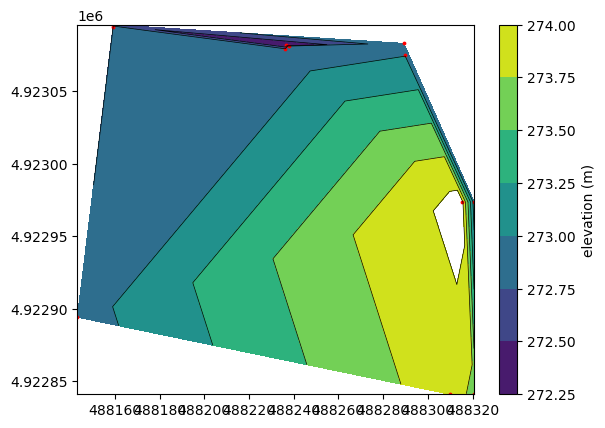

In [81]:
x = data2.x
y = data2.y
z = data2["WaterElevation"]

fig, ax = plt.subplots()
levels = np.arange(z.min(), z.max(), 0.25) #0.25 is the contour interval
contours = ax.tricontourf(x, y, z, levels=levels, cmap = 'viridis')

contourlines = ax.tricontour(x, y, z, levels=levels, colors = 'k', linewidths=0.5)
ax.scatter(x, y, color='red', label = 'piezometer', s = 3)

fig.colorbar(contours, label='elevation (m)')
# ax.legend()
plt.show()

In [82]:
data2

,OID_,Waypoint,Name,WaterElevation,GainingLosing,WaterElevationFT,x,y,geometry
0,2,NaN,P1,272.890015,NaN,895.320007,488159.310482,4.923094e+06,POINT (488159.31 4923094.279)
1,3,NaN,P2,272.820007,NaN,895.090027,488236.136582,4.923079e+06,POINT (488236.137 4923079.035)
2,5,NaN,P3,272.989990,NaN,895.630005,488289.640482,4.923075e+06,POINT (488289.64 4923075.225)
3,6,NaN,P4,274.089996,NaN,899.260010,488315.287282,4.922974e+06,POINT (488315.287 4922973.533)
4,7,NaN,P5,273.880005,NaN,898.559998,488309.809182,4.922841e+06,POINT (488309.809 4922841.107)
5,8,NaN,C1,272.579987,NaN,894.289978,488159.321982,4.923096e+06,POINT (488159.322 4923095.989)
6,9,NaN,C2 upstream,272.929993,NaN,895.440002,488237.688782,4.923081e+06,POINT (488237.689 4923081.029)
7,10,NaN,C2 downstream,272.250000,NaN,893.210022,488236.543082,4.923082e+06,POINT (488236.543 4923081.75)
8,11,NaN,C3,272.970001,NaN,895.570007,488289.242182,4.923083e+06,POINT (488289.242 4923083.066)
9,12,NaN,C4,272.880005,NaN,895.291016,488320.678382,4.922974e+06,POINT (488320.678 4922973.887)


<function matplotlib.pyplot.show(close=None, block=None)>

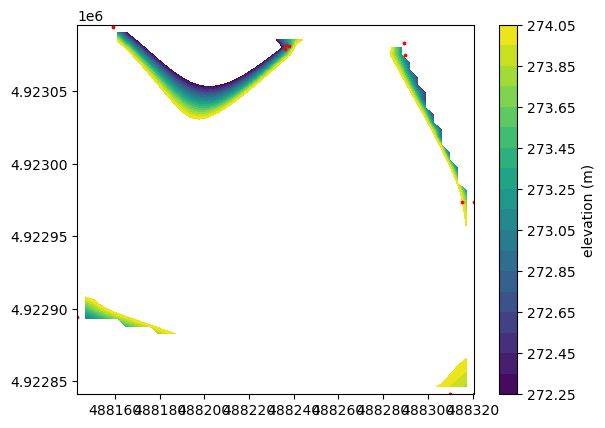

In [89]:
x = data2.x
y = data2.y
z = data2["WaterElevation"]

xi = np.linspace(x.min(), x.max())
yi = np.linspace(y.min(), y.max())
XI, YI = np.meshgrid(xi, yi)

ZI = griddata((x, y), z, (XI, YI), method='cubic')

fig, ax = plt.subplots()
levels = np.arange(z.min(), z.max(), 0.1) #0.1 is the contour interval
contours = ax.contourf(XI, YI, ZI, levels=levels, cmap = "viridis")
# contourlines = ax.contour(XI, YI, ZI, levels=levels, colors = "k", linewidths = 0.5)

ax.scatter(x, y, color='red', label = 'piezometer', s = 3)
fig.colorbar(contours, label='elevation (m)')

plt.show

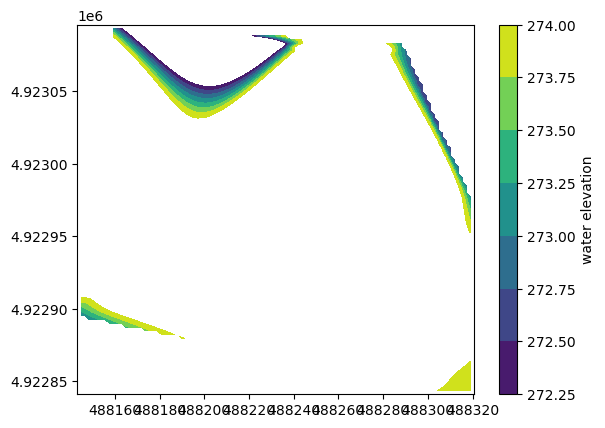

In [84]:
#trying to put it on a square 
x = data2.x
y = data2.y
z = data2["WaterElevation"]

levels = np.arange(z.min(), z.max(), 0.25) #0.25 is the contour interval

# I think this is interpolating the data in data2 onto a grid because it's essentially random points scattered around random space as is
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100), 
    np.linspace(y.min(), y.max(), 100)
)
grid_z = griddata((x, y), z , (grid_x, grid_y), method = 'cubic')

contour_filled = plt.contourf(grid_x, grid_y, grid_z, levels=levels, cmap='viridis')

plt.colorbar(contour_filled, label = 'water elevation')

plt.show()

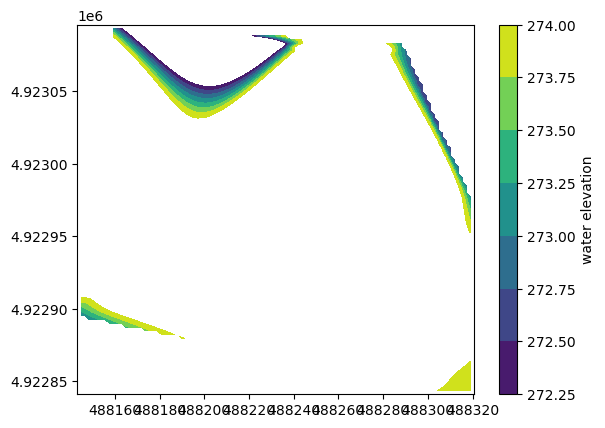

In [85]:
# ok so I am going to pretend that p6 also has a water elevation of 274 and is in the bottom left corner
x = data2.x
y = data2.y
z = data2["WaterElevation"]

levels = np.arange(z.min(), z.max(), 0.25) #0.25 is the contour interval

# I think this is interpolating the data in data2 onto a grid because it's essentially random points scattered around random space as is
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100), 
    np.linspace(y.min(), y.max(), 100)
)
grid_z = griddata((x, y), z , (grid_x, grid_y), method = 'cubic')

contour_filled = plt.contourf(grid_x, grid_y, grid_z, levels=levels, cmap='viridis')

plt.colorbar(contour_filled, label = 'water elevation')

plt.show()